<center><h1>RNN</h1></center>

---


In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()

        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accurate = 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            accurate += (preds.argmax(1) == y).sum().item()

    test_loss /= num_batches
    accurate /= size

    print(
        f"Test Error :\n Avg Loss : {test_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
    )

    return test_loss, accurate


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

## Auto Regressive

### One-step


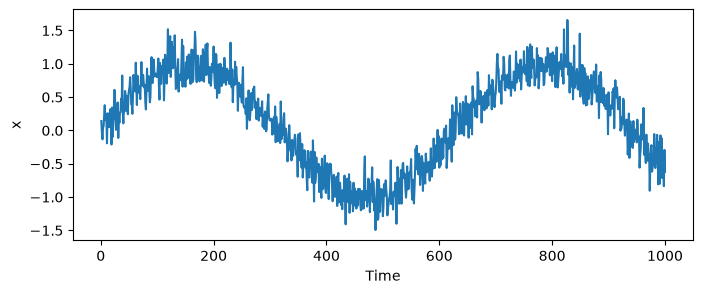

In [3]:
import torch
import matplotlib.pyplot as plt

T = 1000
tau = 4
num_train = 600
batch_size = 16

time = torch.arange(1, T + 1, dtype=torch.float32)

# Sine wave + noise
x = torch.sin(0.01 * time) + torch.randn(T) * 0.2

plt.figure(figsize=(8, 3))
plt.plot(time.numpy(), x.numpy())
plt.xlabel("Time")
plt.ylabel("x")
plt.show()

In [4]:
features = []
labels = []

device = "cpu"

for i in range(T - tau):
    features.append(x[i : i + tau])
    labels.append(x[i + tau])

features = torch.stack(features).to(device)
labels = torch.tensor(labels).reshape(-1, 1).to(device)

print(features.shape)
print(labels.shape)

torch.Size([996, 4])
torch.Size([996, 1])


In [5]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train = features[:num_train]
y_train = labels[:num_train]

X_test = features[num_train:]
y_test = labels[num_train:]


train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
import torch.nn as nn

model = nn.Linear(4, 1).to(device)

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Epoch : 1---------------------------------------
Loss : 0.469335 [  16 /  600]
Loss : 0.088946 [ 304 /  600]
Test Error :
 Avg Loss : 0.077149 | Accuracy : 0.0% 

Epoch : 2---------------------------------------
Loss : 0.094819 [  16 /  600]
Loss : 0.040848 [ 304 /  600]
Test Error :
 Avg Loss : 0.067314 | Accuracy : 0.0% 

Epoch : 3---------------------------------------
Loss : 0.078577 [  16 /  600]
Loss : 0.094825 [ 304 /  600]
Test Error :
 Avg Loss : 0.066711 | Accuracy : 0.0% 

Epoch : 4---------------------------------------
Loss : 0.054313 [  16 /  600]
Loss : 0.065007 [ 304 /  600]
Test Error :
 Avg Loss : 0.066176 | Accuracy : 0.0% 

Epoch : 5---------------------------------------
Loss : 0.074062 [  16 /  600]
Loss : 0.030500 [ 304 /  600]
Test Error :
 Avg Loss : 0.065645 | Accuracy : 0.0% 



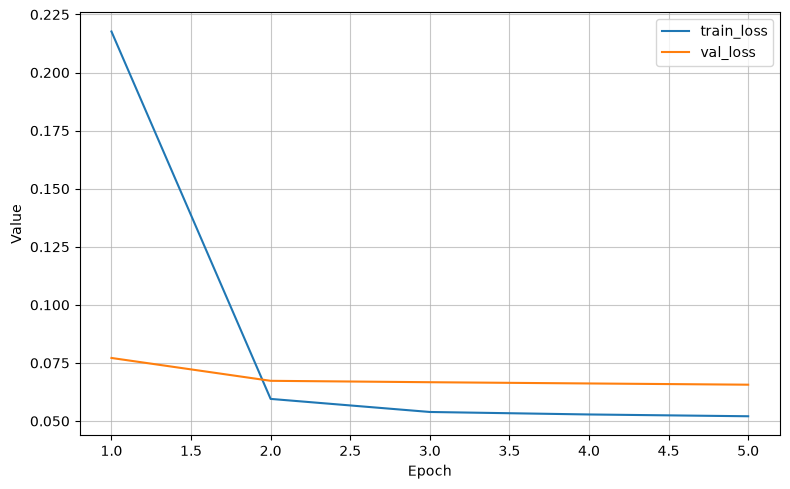

In [7]:
history = {"train_loss": [], "val_loss": []}

epochs = 5
for epoch in range(epochs):
    print(f"Epoch : {epoch+1}---------------------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss, val_acc = test(model, test_dataloader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

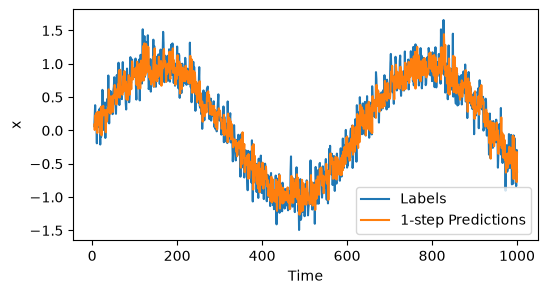

In [8]:
model.eval()

with torch.no_grad():
    one_step_preds = model(features)

plt.figure(figsize=(6, 3))

plt.plot(time[tau:].cpu().numpy(), labels.cpu().numpy(), label="Labels")

plt.plot(
    time[tau:].cpu().numpy(), one_step_preds.cpu().numpy(), label="1-step Predictions"
)

plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()

### k-step-ahead


C:\Users\USER\AppData\Local\Temp\ipykernel_21844\3846807309.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


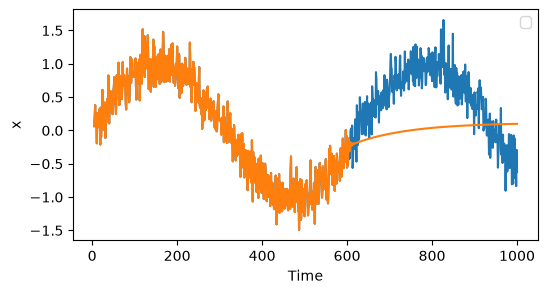

In [9]:
model.eval()

multistep_preds = x.clone()

with torch.no_grad():

    for i in range(num_train + tau, T):

        window = multistep_preds[i - tau : i].reshape(1, tau)

        prediction = model(window)

        multistep_preds[i] = prediction.squeeze()

plt.figure(figsize=(6, 3))

plt.plot(time[tau:].cpu().numpy(), labels.cpu().numpy())

plt.plot(time[tau:].cpu().numpy(), multistep_preds[tau:].cpu().numpy())

plt.xlabel("Time")
plt.ylabel("x")
plt.legend()
plt.show()

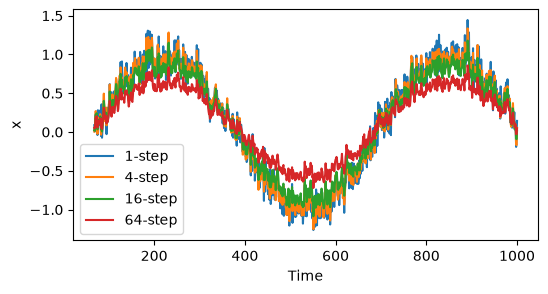

In [10]:
def k_step_pred(model, x, tau, k):
    model.eval()

    features = []

    # Initial true observations
    for i in range(tau):
        features.append(x[i : i + len(x) - tau - k + 1])

    with torch.no_grad():

        for i in range(k):

            window = torch.stack(features[i : i + tau], dim=1)

            pred = model(window).squeeze()

            features.append(pred)

    return features[tau:]


steps = [1, 4, 16, 64]
preds = k_step_pred(model, x, tau=4, k=64)

x_axis = time[tau + steps[-1] - 1 :].cpu()

plt.figure(figsize=(6, 3))

for s in steps:
    plt.plot(x_axis, preds[s - 1].cpu().numpy(), label=f"{s}-step")

plt.legend()
plt.xlabel("Time")
plt.ylabel("x")
plt.show()

## Converting Raw Text into Data


> **Typical Text Preprocessing Pipeline**

---

A typical text preprocessing pipeline consists of the following steps:

1. **Load text into memory**
   - Read the text data as strings.

2. **Tokenize the text**
   - Split the text into smaller units called **tokens** (e.g., words, subwords, or characters).

3. **Build a vocabulary**
   - Create a vocabulary dictionary that maps each unique token to a numerical index.

4. **Convert text to numerical sequences**
   - Replace each token in the text with its corresponding numerical index to produce sequences that can be used as input for machine learning models.


In [11]:
import collections
import random
import re
import torch
import matplotlib.pyplot as plt

In [12]:
import os
import urllib.request

url = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"

# Ensure the data directory exists
os.makedirs("data", exist_ok=True)

# Save the dataset in data/
filename = "data/timemachine.txt"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print(f"Dataset saved to {filename}")

with open("data/timemachine.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

# print("Text")
print(raw_text[:100])

The Time Machine, by H. G. Wells [1898]




I


The Time Traveller (for so it will be convenient to 


In [13]:
def _preprocess(text):
    return re.sub("[^A-Za-z]+", " ", text).lower()


text = _preprocess(raw_text)
text[:100]

'the time machine by h g wells i the time traveller for so it will be convenient to speak of him was '

In [14]:
tokens = list(text)
",".join(tokens[:100])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, ,i, ,t,h,e, ,t,i,m,e, ,t,r,a,v,e,l,l,e,r, ,f,o,r, ,s,o, ,i,t, ,w,i,l,l, ,b,e, ,c,o,n,v,e,n,i,e,n,t, ,t,o, ,s,p,e,a,k, ,o,f, ,h,i,m, ,w,a,s, '

In [15]:
from collections import Counter


class Vocab:
    def __init__(self, tokens=[], reserved_tokens=[], min_freq=0) -> None:
        # Flatten 2d lists if needed
        if tokens and isinstance(tokens[0], (list, tuple)):
            tokens = [token for line in tokens for token in line]

        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = list(
            sorted(
                set(
                    ["<unk>"]
                    + reserved_tokens
                    + [token for token, freq in self.token_freqs if freq >= min_freq]
                )
            )
        )
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_token[idx] for idx in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):
        return self.token_to_idx["<unk>"]

In [16]:
vocab = Vocab(tokens)
indices = vocab[tokens[:10]]
print("indices:", indices)
print("words:", vocab.to_tokens(indices))

indices: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14]
words: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']


In [17]:
text = _preprocess(raw_text)
tokens = list(text)
vocab = Vocab(tokens)
corpus = vocab[tokens]
len(corpus), len(vocab)

(173428, 28)

In [18]:
words = text.split()
vocab = Vocab(words)
print(f"10 Most frequent tokens")
vocab.token_freqs[:10]

10 Most frequent tokens


[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

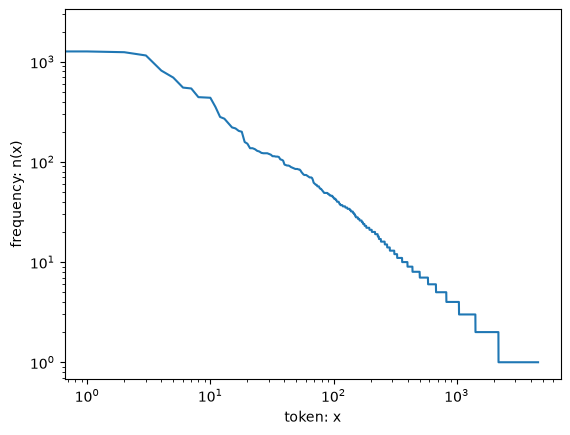

In [19]:
freqs = [freq for _, freq in vocab.token_freqs]
plt.plot(freqs)
plt.xlabel("token: x")
plt.ylabel("frequency: n(x)")
plt.xscale("log")
plt.yscale("log")
plt.show()

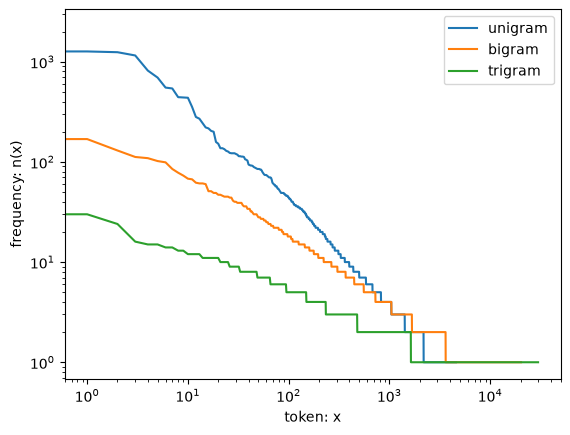

In [20]:
# Bigram
bigram_tokens = ["--".join(pair) for pair in zip(words[:-1], words[1:])]
bigram_vocab = Vocab(bigram_tokens)
bigram_freqs = [freq for _, freq in bigram_vocab.token_freqs]

# Trigram
trigram_tokens = [
    "--".join(triple) for triple in zip(words[:-2], words[1:-1], words[2:])
]
trigram_vocab = Vocab(trigram_tokens)
trigram_freqs = [freq for _, freq in trigram_vocab.token_freqs]


plt.plot(freqs, label="unigram")
plt.plot(bigram_freqs, label="bigram")
plt.plot(trigram_freqs, label="trigram")

plt.xlabel("token: x")
plt.ylabel("frequency: n(x)")
plt.xscale("log")
plt.yscale("log")
plt.legend()

plt.show()

This proves that the frequency of words tends to follow Zipf’s law. This is true not just for individual words (unigrams), but also for 𝑛-grams


In [21]:
import numpy as np


def estimate_alpha(freqs):
    ranks = np.arange(1, len(freqs) + 1)

    log_ranks = np.log(ranks)
    log_freqs = np.log(freqs)

    slope, intercept = np.polyfit(log_ranks, log_freqs, 1)
    alpha, C = -slope, np.exp(intercept)

    return alpha, C


print("Unigram α:", estimate_alpha(freqs))
print("Bigram α:", estimate_alpha(bigram_freqs))
print("Trigram α:", estimate_alpha(trigram_freqs))

Unigram α: (np.float64(1.035290677007962), np.float64(4555.600010388708))
Bigram α: (np.float64(0.4637430309938128), np.float64(76.42222400490307))
Trigram α: (np.float64(0.16419035983315813), np.float64(4.841128312783503))


### Partitioning Sequences

For each epoch:

1. **Start with one long sequence of token IDs.**

   Example:

   ```text
   [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
   ```

2. **Randomly choose an offset `d` between `0` and `n - 1`.**

   For example, if `n = 4`:

   ```text
   d ∈ {0, 1, 2, 3}
   ```

3. **Discard the first `d` tokens.**

   If `d = 2`:

   ```text
   Original:
   [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

   After discarding:
   [30, 40, 50, 60, 70, 80, 90, 100]
   ```

4. **Split the remaining sequence into non-overlapping chunks of length `n`.**

   For `n = 4`:

   ```text
   [30, 40, 50, 60]
   [70, 80, 90, 100]
   ```

5. **Use each chunk as an input sequence.**

   Example:

   ```text
   Input:
   [30, 40, 50, 60]
   ```

6. **Use the same chunk shifted one token to the right as the target sequence.**

   ```text
   Input : [30, 40, 50, 60]
   Target: [40, 50, 60, 70]
   ```

   So the model learns:

   ```text
   30 → 40
   40 → 50
   50 → 60
   60 → 70
   ```


In [22]:
from collections import Counter


class Vocab:
    def __init__(self, tokens=[], reserved_tokens=[], min_freq=0) -> None:
        # Flatten 2d lists if needed
        if tokens and isinstance(tokens[0], (list, tuple)):
            tokens = [token for line in tokens for token in line]

        counter = Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = list(
            sorted(
                set(
                    ["<unk>"]
                    + reserved_tokens
                    + [token for token, freq in self.token_freqs if freq >= min_freq]
                )
            )
        )
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_token[idx] for idx in indices]
        return self.idx_to_token[indices]

    @property
    def unk(self):
        return self.token_to_idx["<unk>"]

In [23]:
import re
import torch
import os
import urllib.request
from torch.utils.data import TensorDataset, DataLoader


class TimeMachine:
    URL = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"

    def __init__(self, batch_size=32, num_steps=35, num_train=10000, num_val=5000):

        self.batch_size = batch_size
        self.num_steps = num_steps
        self.num_train = num_train
        self.num_val = num_val

        raw_text = self._download()

        self.corpus, self.vocab = self.build(raw_text)

        # Create sliding windows
        array = torch.tensor(
            [
                self.corpus[i : i + num_steps + 1]
                for i in range(len(self.corpus) - num_steps)
            ],
            dtype=torch.long,
        )

        self.X = array[:, :-1]
        self.Y = array[:, 1:]

    def _download(self):
        os.makedirs("data", exist_ok=True)

        filename = "data/timemachine.txt"

        if not os.path.exists(filename):
            urllib.request.urlretrieve(self.URL, filename)

        with open(filename, "r", encoding="utf-8") as f:
            return f.read()

    def _preprocess(self, text):
        """Replace non-letters with spaces and lowercase."""
        return re.sub(r"[^A-Za-z]+", " ", text).lower()

    def _tokenize(self, text):
        """Character-level tokenization."""
        return list(text)

    def build(self, raw_text, vocab=None):
        tokens = self._tokenize(self._preprocess(raw_text))

        if vocab is None:
            vocab = Vocab(tokens)

        corpus = vocab[tokens]

        return corpus, vocab

    def get_dataloader(self, train=True):
        if train:
            idx = slice(0, self.num_train)
        else:
            idx = slice(self.num_train, self.num_train + self.num_val)

        dataset = TensorDataset(self.X[idx], self.Y[idx])

        return DataLoader(dataset, batch_size=self.batch_size, shuffle=train)

    def train_dataloader(self):
        return self.get_dataloader(train=True)

    def val_dataloader(self):
        return self.get_dataloader(train=False)

In [24]:
data = TimeMachine(batch_size=2, num_steps=10)

for X, Y in data.train_dataloader():
    print(X)
    print(Y)
    break

tensor([[ 0,  2, 15,  5,  0, 24,  9, 26,  0, 20],
        [15,  4,  6,  0, 16,  7,  0, 21,  9,  6]])
tensor([[ 2, 15,  5,  0, 24,  9, 26,  0, 20,  9],
        [ 4,  6,  0, 16,  7,  0, 21,  9,  6,  0]])


## RNN From Scratch


In [52]:
import math
import torch
from torch import nn
import torch.nn.functional as F

In [53]:
from typing import Any


class RNN(nn.Module):
    def __init__(self, num_inputs, num_hiddens, sigma=0.01) -> None:
        super().__init__()

        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.sigma = sigma

        self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros(
                (inputs.shape[1], self.num_hiddens), device=inputs.device
            )
        elif isinstance(state, tuple):
            state = state[0]
        outputs = []
        for x in inputs:  # shape of inputs : (num_steps, batch_size, num_inputs)
            state = torch.tanh(
                torch.matmul(x, self.W_xh) + torch.matmul(state, self.W_hh) + self.b_h
            )
            outputs.append(state)
        return outputs, state

In [54]:
batch_size, num_inputs, num_hiddens, num_steps = 2, 16, 32, 100
rnn = RNN(num_inputs, num_hiddens)
X = torch.ones((num_steps, batch_size, num_inputs))
rnn.forward(X)

([tensor([[-7.1779e-02,  1.4486e-03,  2.6842e-02, -4.2023e-02, -9.1026e-03,
            1.4329e-02,  2.0765e-03,  3.0003e-02, -2.5362e-03, -2.9631e-02,
           -4.3997e-03,  3.3490e-02, -4.9914e-02,  5.9060e-02,  1.3639e-02,
            1.5431e-02,  3.8160e-02,  8.4382e-03, -4.9694e-03, -4.2783e-02,
            1.0192e-02, -2.0216e-02, -1.1821e-02,  4.0943e-02, -9.3909e-05,
           -2.0772e-02, -8.4541e-02,  1.3525e-02, -4.2511e-02, -2.8822e-02,
           -1.1668e-02,  2.4462e-02],
          [-7.1779e-02,  1.4486e-03,  2.6842e-02, -4.2023e-02, -9.1026e-03,
            1.4329e-02,  2.0765e-03,  3.0003e-02, -2.5362e-03, -2.9631e-02,
           -4.3997e-03,  3.3490e-02, -4.9914e-02,  5.9060e-02,  1.3639e-02,
            1.5431e-02,  3.8160e-02,  8.4382e-03, -4.9694e-03, -4.2783e-02,
            1.0192e-02, -2.0216e-02, -1.1821e-02,  4.0943e-02, -9.3909e-05,
           -2.0772e-02, -8.4541e-02,  1.3525e-02, -4.2511e-02, -2.8822e-02,
           -1.1668e-02,  2.4462e-02]], grad_fn=<Ta

In [55]:
from typing import Any


class RNNLM(nn.Module):
    def __init__(self, rnn, vocab_size, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.rnn = rnn
        self.vocab_size = vocab_size

        self.W_hq = nn.Parameter(torch.randn(rnn.num_hiddens, vocab_size) * rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(vocab_size))

    def forward(self, X, state=None):
        embs = self.one_hot(X)
        rnn_outputs, state = self.rnn(embs, state)
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, 1), state

    def one_hot(self, X):
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)

    def predict(self, prefix, num_preds, vocab):
        self.eval()

        state, outputs = None, [vocab[prefix[0]]]

        for i in range(len(prefix) + num_preds - 1):

            X = torch.tensor([[outputs[-1]]], dtype=torch.long, device=self.b_q.device)

            logits, state = self(X, state)

            if i < len(prefix) - 1:
                outputs.append(vocab[prefix[i + 1]])
            else:
                outputs.append(logits.argmax(dim=-1).item())

        return "".join(vocab.idx_to_token[idx] for idx in outputs)

In [56]:
# from typing import Any


# class RNN(nn.Module):
#     def __init__(
#         self,
#         num_hiddens,
#         num_inputs,
#         num_outputs,
#         sigma=0.01,
#         *args: Any,
#         **kwargs: Any
#     ) -> None:
#         super().__init__(*args, **kwargs)

#         self.num_hiddens = num_hiddens
#         self.num_inputs = num_inputs
#         self.num_outputs = num_outputs

#         self.W_xh = nn.Parameter(torch.randn(num_inputs, num_hiddens) * sigma)
#         self.W_hh = nn.Parameter(torch.randn(num_hiddens, num_hiddens) * sigma)
#         self.b_h = nn.Parameter(torch.zeros(num_hiddens))

#         self.W_hq = nn.Parameter(torch.randn(num_hiddens, num_outputs) * sigma)
#         self.b_q = nn.Parameter(torch.zeros(num_outputs))

#     def forward(self, inputs, state=None):
#         if state is None:
#             state = torch.zeros(inputs.shape[1], self.num_hiddens)
#         else:
#             (state,) = state

#         inputs = inputs.transpose(0, 1)
#         outputs = []
#         for x in inputs:
#             state = torch.tanh(
#                 torch.matmul(x, self.W_xh) + torch.matmul(state, self.W_hh) + self.b_h
#             )
#             outputs.append(state)

#         outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in outputs]
#         return torch.stack(outputs, 1), (state,)

In [57]:
def clip_gradient(thresh, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad**2) for p in params))

    if norm > thresh:
        for p in params:
            p.grad[:] *= thresh / norm

In [58]:
data = TimeMachine(batch_size=1024, num_steps=32)
train_dataloader = data.get_dataloader(train=True)
test_dataloader = data.get_dataloader(train=False)

device = (
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

rnn = RNN(num_inputs=len(data.vocab), num_hiddens=32).to(device)
model = RNNLM(rnn, vocab_size=len(data.vocab)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)

In [59]:
def train_rnn(model, dataloader, device, loss_fn, optimizer):
    total_n = len(dataloader.dataset)
    num_batches = len(dataloader)
    total_loss = 0

    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        logits, state = model(X, None)
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), y.reshape(-1))
        total_loss += loss.item()

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        if isinstance(state, tuple):
            state = tuple(s.detach() for s in state)
        else:
            state = (state.detach(),)

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {total_n:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {total_n:>4d}]")

    return total_loss / num_batches


def test_rnn(model, dataloader, device, loss_fn):
    num_batches = len(dataloader)

    total_loss, accurate, total_toks = 0, 0, 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            logits, _ = model(X)
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), y.reshape(-1))
            total_loss += loss.item()

            preds = logits.argmax(-1)
            accurate += (preds == y).sum().item()

            total_toks += y.numel()

        total_loss /= num_batches
        accurate /= total_toks

        print(
            f"Test Error :\n Avg Loss : {total_loss:>7f} | Accuracy : {100 * accurate:>0.1f}% \n"
        )

        return total_loss, accurate

Epoch 1 ------------------------------------------
Loss : 3.332184 [1024 / 10000]
Loss : 3.067754 [7840 / 10000]
Test Error :
 Avg Loss : 3.041485 | Accuracy : 18.8% 

Epoch 2 ------------------------------------------
Loss : 3.052709 [1024 / 10000]
Loss : 2.959291 [7840 / 10000]
Test Error :
 Avg Loss : 2.939180 | Accuracy : 18.8% 

Epoch 3 ------------------------------------------
Loss : 2.949623 [1024 / 10000]
Loss : 2.910441 [7840 / 10000]
Test Error :
 Avg Loss : 2.889843 | Accuracy : 18.8% 

Epoch 4 ------------------------------------------
Loss : 2.904625 [1024 / 10000]
Loss : 2.883087 [7840 / 10000]
Test Error :
 Avg Loss : 2.854280 | Accuracy : 18.8% 

Epoch 5 ------------------------------------------
Loss : 2.875411 [1024 / 10000]
Loss : 2.848314 [7840 / 10000]
Test Error :
 Avg Loss : 2.823822 | Accuracy : 18.8% 

Epoch 6 ------------------------------------------
Loss : 2.845296 [1024 / 10000]
Loss : 2.825019 [7840 / 10000]
Test Error :
 Avg Loss : 2.794098 | Accuracy : 

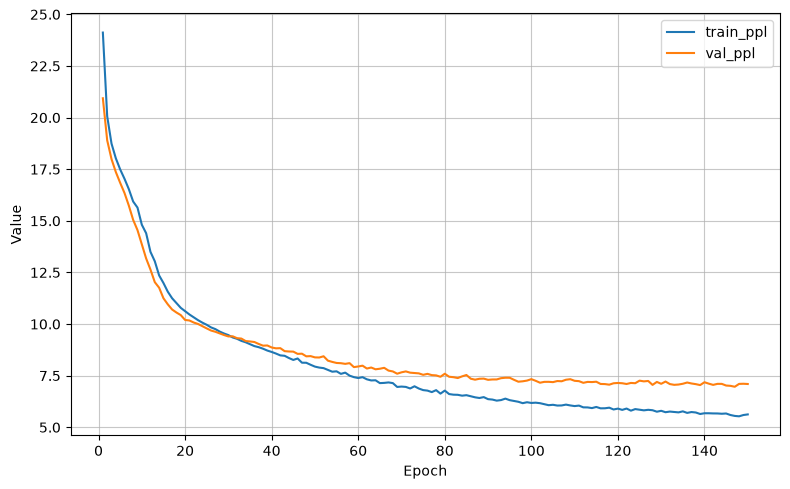

In [60]:
history = {"train_ppl": [], "val_ppl": []}


epochs = 150
for epoch in range(epochs):
    print(f"Epoch {epoch + 1} ------------------------------------------")
    train_loss = train_rnn(model, train_dataloader, device, loss_fn, optimizer)
    val_loss, val_acc = test_rnn(model, test_dataloader, device, loss_fn)

    history["train_ppl"].append(torch.exp(torch.tensor(train_loss)).item())
    history["val_ppl"].append(torch.exp(torch.tensor(val_loss)).item())

plot_net(history)

In [61]:
model.predict("he is a ", 50, data.vocab)

'he is a sough and the time traveller a movered and the tim'

## LSTM


In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class LSTMLM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.vocab_size = vocab_size

        self.lstm = nn.LSTM(
            input_size=vocab_size, hidden_size=hidden_size, batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, X, state=None):
        # X: (batch_size, seq_len)

        X = F.one_hot(X, self.vocab_size).float()

        outputs, state = self.lstm(X, state)

        logits = self.fc(outputs)

        return logits, state

    def predict(self, prefix, num_preds, vocab):
        self.eval()

        state, outputs = None, [vocab[prefix[0]]]

        for i in range(len(prefix) + num_preds - 1):
            x = torch.tensor(
                [[outputs[-1]]],
                dtype=torch.long,
                device=(next(self.parameters())).device,
            )
            logits, state = self(x, state)

            if i < len(prefix) - 1:
                outputs.append(vocab[prefix[i + 1]])
            else:
                outputs.append(logits[:, -1].argmax(-1).item())

        return "".join(vocab.idx_to_token[idx] for idx in outputs)

In [74]:
data = TimeMachine(64, 32)
train_dataloader = data.get_dataloader(train=True)
test_dataloader = data.get_dataloader(train=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMLM(len(data.vocab), hidden_size=32).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)

Epoch : 1 ---------------------------------------
Loss : 3.331440 [  64 / 10000]
Loss : 2.666182 [2512 / 10000]
Test Error :
 Avg Loss : 2.662601 | Accuracy : 24.7% 

Epoch : 2 ---------------------------------------
Loss : 2.708878 [  64 / 10000]
Loss : 2.388050 [2512 / 10000]
Test Error :
 Avg Loss : 2.357230 | Accuracy : 32.9% 

Epoch : 3 ---------------------------------------
Loss : 2.383085 [  64 / 10000]
Loss : 2.252832 [2512 / 10000]
Test Error :
 Avg Loss : 2.254437 | Accuracy : 33.4% 

Epoch : 4 ---------------------------------------
Loss : 2.340261 [  64 / 10000]
Loss : 2.275503 [2512 / 10000]
Test Error :
 Avg Loss : 2.209710 | Accuracy : 34.2% 

Epoch : 5 ---------------------------------------
Loss : 2.161394 [  64 / 10000]
Loss : 2.113594 [2512 / 10000]
Test Error :
 Avg Loss : 2.118447 | Accuracy : 36.6% 

Epoch : 6 ---------------------------------------
Loss : 2.085409 [  64 / 10000]
Loss : 1.999028 [2512 / 10000]
Test Error :
 Avg Loss : 2.075651 | Accuracy : 38.1% 

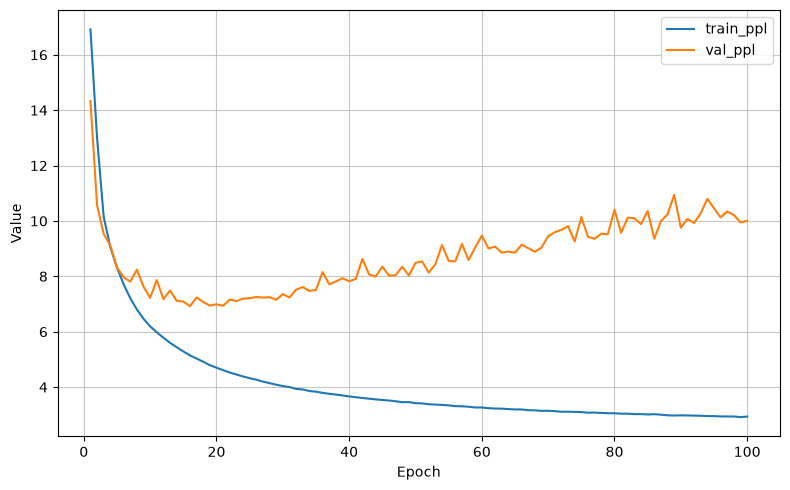

In [ ]:
history_dict = {"train_ppl": [], "val_ppl": []}

epochs = 100
for epoch in range(epochs):
    print(f"Epoch : {epoch + 1} ---------------------------------------")
    train_loss = train_rnn(model, train_dataloader, device, loss_fn, optimizer)
    val_loss, val_acc = test_rnn(model, test_dataloader, device, loss_fn)

    history_dict["train_ppl"].append(torch.exp(torch.tensor(train_loss)).item())
    history_dict["val_ppl"].append(torch.exp(torch.tensor(val_loss)).item())

plot_net(history_dict)

In [76]:
model.predict("he is a", 50, data.vocab)

'he is a mathematical then the of thing sciental existence'

## GRU

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class GRULM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()

        self.vocab_size = vocab_size

        self.gru = nn.GRU(
            input_size=vocab_size, hidden_size=hidden_size, batch_first=True
        )

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, X, state=None):
        # X: (batch_size, seq_len)

        X = F.one_hot(X, self.vocab_size).float()

        outputs, state = self.gru(X, state)

        logits = self.fc(outputs)

        return logits, state

    def predict(self, prefix, num_preds, vocab):
        self.eval()

        state, outputs = None, [vocab[prefix[0]]]

        for i in range(len(prefix) + num_preds - 1):
            x = torch.tensor(
                [[outputs[-1]]],
                dtype=torch.long,
                device=(next(self.parameters())).device,
            )
            logits, state = self(x, state)

            if i < len(prefix) - 1:
                outputs.append(vocab[prefix[i + 1]])
            else:
                outputs.append(logits[:, -1].argmax(-1).item())

        return "".join(vocab.idx_to_token[idx] for idx in outputs)

In [78]:
data = TimeMachine(64, 32)
train_dataloader = data.get_dataloader(train=True)
test_dataloader = data.get_dataloader(train=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = GRULM(len(data.vocab), hidden_size=32).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1)

Epoch : 1 ---------------------------------------
Loss : 3.314862 [  64 / 10000]
Loss : 2.513747 [2512 / 10000]
Test Error :
 Avg Loss : 2.391703 | Accuracy : 32.2% 

Epoch : 2 ---------------------------------------
Loss : 2.423542 [  64 / 10000]
Loss : 2.292948 [2512 / 10000]
Test Error :
 Avg Loss : 2.294319 | Accuracy : 33.5% 

Epoch : 3 ---------------------------------------
Loss : 2.283901 [  64 / 10000]
Loss : 2.053105 [2512 / 10000]
Test Error :
 Avg Loss : 2.143390 | Accuracy : 36.2% 

Epoch : 4 ---------------------------------------
Loss : 2.104526 [  64 / 10000]
Loss : 2.095485 [2512 / 10000]
Test Error :
 Avg Loss : 2.079701 | Accuracy : 37.9% 

Epoch : 5 ---------------------------------------
Loss : 1.972349 [  64 / 10000]
Loss : 2.051804 [2512 / 10000]
Test Error :
 Avg Loss : 2.039865 | Accuracy : 38.9% 

Epoch : 6 ---------------------------------------
Loss : 1.987771 [  64 / 10000]
Loss : 1.936557 [2512 / 10000]
Test Error :
 Avg Loss : 1.997274 | Accuracy : 41.5% 

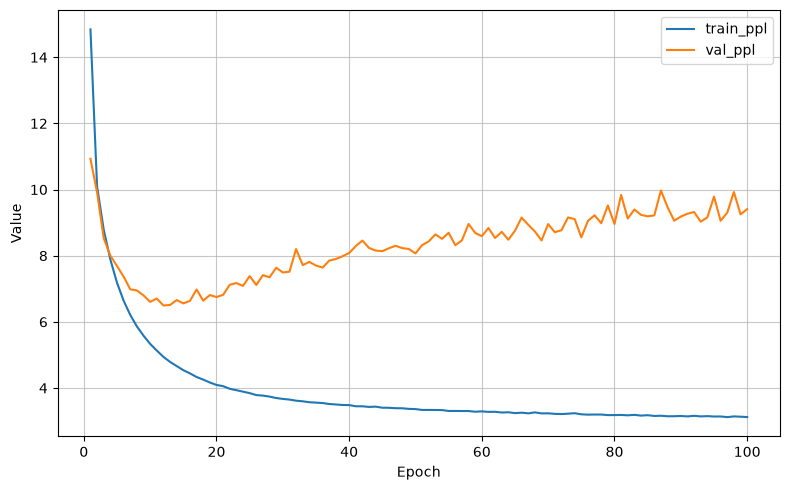

In [79]:
history_dict = {"train_ppl": [], "val_ppl": []}

epochs = 100
for epoch in range(epochs):
    print(f"Epoch : {epoch + 1} ---------------------------------------")
    train_loss = train_rnn(model, train_dataloader, device, loss_fn, optimizer)
    val_loss, val_acc = test_rnn(model, test_dataloader, device, loss_fn)

    history_dict["train_ppl"].append(torch.exp(torch.tensor(train_loss)).item())
    history_dict["val_ppl"].append(torch.exp(torch.tensor(val_loss)).item())

plot_net(history_dict)

In [101]:
model.predict("qwertyuiopasdfghjklzxcvbnmasdfghjk", 52, data.vocab)

'qwertyuiopasdfghjklzxcvbnmasdfghjkns got you said the time traveller mome about and th'

## Encoder-Decoder Architecture

In [88]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    """Base encoder class."""

    def __init__(self):
        super().__init__()

    def forward(self, X, *args):
        raise NotImplementedError


class Decoder(nn.Module):
    """Base decoder class."""

    def __init__(self):
        super().__init__()

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

In [89]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        outputs, state = self.decoder(dec_X, dec_state)
        return outputs